In [1]:
import pandas as pd
import pingouin as pg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import statsmodels.api as sm

/Users/mariairenetenerani/anaconda3/envs/Apple_tensorflow_env/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [ ]:
#Load csv file into dataframe
df = pd.read_csv('../../../RadiomiK/Features_Global/rect0_glob.csv')
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition
0,32073.0,32600.0,2.945270e+12,4.957860,343.00,2.007931,32902.0,174.278064,32339.828835,32340.5,...,302.342795,0.002508,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1
1,32062.0,32601.0,2.944749e+12,4.989626,353.00,2.029146,32959.0,177.717561,32336.942116,32336.0,...,302.393634,0.002757,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2
2,32062.0,32592.5,2.944623e+12,4.964803,354.00,1.973207,32875.0,177.517125,32336.259233,32340.0,...,239.067813,0.005203,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3
3,32102.0,32568.0,2.944755e+12,4.804629,291.00,2.121743,32853.0,151.574896,32337.149503,32340.0,...,226.980238,0.003405,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1
4,32092.0,32561.0,2.944401e+12,4.792798,293.25,2.100375,32878.0,151.569245,32335.203835,32341.0,...,226.558783,0.002847,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3
5,32098.0,32563.5,2.944277e+12,4.819793,288.25,2.231976,32872.0,149.954805,32334.519176,32336.0,...,252.408168,0.002617,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2
6,32046.5,32611.0,2.944638e+12,5.047868,376.25,1.955196,32892.0,189.465702,32336.256037,32340.0,...,384.390702,0.001964,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3
7,32046.0,32615.0,2.944746e+12,5.068907,376.00,2.007995,32991.0,189.258119,32336.840909,32338.0,...,367.608456,0.002365,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2
8,32058.0,32617.0,2.945413e+12,5.033386,367.00,1.985071,32937.0,185.349129,32340.538707,32344.0,...,334.363709,0.002482,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1
9,32067.0,32592.5,2.944197e+12,4.984308,328.00,2.191693,32920.0,170.480902,32333.945312,32334.0,...,334.702319,0.002430,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2


In [3]:
#Scale the data
scaler = MinMaxScaler()
df_reduced= df.iloc[:, :86]
df_last = df.iloc[:, 86:]
df_scaled = pd.DataFrame(scaler.fit_transform(df_reduced.iloc[:, :86]), columns=df_reduced.columns)
df_joined = df_scaled.join(df_last)
df = df_joined
df_joined

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition
0,0.100332,0.028078,0.788870,0.283583,0.299051,0.064849,0.030740,0.208402,0.011192,0.006635,...,0.167845,0.053080,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1
1,0.091211,0.028798,0.788510,0.312859,0.320148,0.079833,0.066499,0.223899,0.008466,0.002370,...,0.167911,0.064130,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2
2,0.091211,0.022678,0.788423,0.289982,0.322257,0.040324,0.013802,0.222996,0.007821,0.006161,...,0.085894,0.172668,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3
3,0.124378,0.005040,0.788514,0.142366,0.189346,0.145233,0.000000,0.106110,0.008662,0.006161,...,0.070238,0.092902,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1
4,0.116086,0.000000,0.788270,0.131463,0.194093,0.130141,0.015684,0.106084,0.006825,0.007109,...,0.069693,0.068145,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3
5,0.121061,0.001800,0.788184,0.156341,0.183544,0.223089,0.011920,0.098810,0.006178,0.002370,...,0.103172,0.057924,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2
6,0.078358,0.035997,0.788433,0.366535,0.369198,0.027603,0.024467,0.276832,0.007818,0.006161,...,0.274111,0.028942,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3
7,0.077944,0.038877,0.788508,0.385924,0.368671,0.064895,0.086575,0.275896,0.008370,0.004265,...,0.252375,0.046744,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2
8,0.087894,0.040317,0.788969,0.353188,0.349684,0.048703,0.052698,0.258284,0.011862,0.009953,...,0.209318,0.051945,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1
9,0.095357,0.022678,0.788128,0.307958,0.267405,0.194638,0.042033,0.191293,0.005636,0.000474,...,0.209756,0.049612,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2


In [4]:
#AGGIUNGO LA COLONNA PROTOCOLLO
# Define conditions and corresponding values for the new column
conditions = [
    (df['Dose'] == 2) & (df['ASIR'] == 'FBP') & (df['Manufacturer'] == 'GE MEDICAL SYSTEMS'), (df['Dose'] == 2) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 2) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 2) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 4) & (df['ASIR'] == 'FBP'), (df['Dose'] == 4) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 4) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 4) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 7) & (df['ASIR'] == 'FBP'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 7) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 14) & (df['ASIR'] == 'FBP'), (df['Dose'] == 14) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 14) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 14) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 2) & (df['ASIR'] == 'FBP') & (df['Manufacturer'] == 'TOSHIBA'), (df['Dose'] == 2) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 2) & (df['ASIR'] == 'STD'), (df['Dose'] == 2) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 4) & (df['ASIR'] == 'FBP'), (df['Dose'] == 4) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 4) & (df['ASIR'] == 'STD'), (df['Dose'] == 4) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 8) & (df['ASIR'] == 'FBP'), (df['Dose'] == 8) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 8) & (df['ASIR'] == 'STD'), (df['Dose'] == 8) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 16) & (df['ASIR'] == 'FBP'), (df['Dose'] == 16) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 16) & (df['ASIR'] == 'STD'), (df['Dose'] == 16) & (df['ASIR'] == 'STRONG'),
    ]

new_column_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
                     27, 28, 29, 30, 31, 32]

# Add a new column based on the conditions
df['PROTOCOL'] = np.select(conditions, new_column_values, default=None)

# Print the updated DataFrame
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,original_gldm_SmallDependenceLowGrayLevelEmphasis,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL
0,0.100332,0.028078,0.788870,0.283583,0.299051,0.064849,0.030740,0.208402,0.011192,0.006635,...,0.053080,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1,24
1,0.091211,0.028798,0.788510,0.312859,0.320148,0.079833,0.066499,0.223899,0.008466,0.002370,...,0.064130,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2,24
2,0.091211,0.022678,0.788423,0.289982,0.322257,0.040324,0.013802,0.222996,0.007821,0.006161,...,0.172668,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3,24
3,0.124378,0.005040,0.788514,0.142366,0.189346,0.145233,0.000000,0.106110,0.008662,0.006161,...,0.092902,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1,20
4,0.116086,0.000000,0.788270,0.131463,0.194093,0.130141,0.015684,0.106084,0.006825,0.007109,...,0.068145,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3,20
5,0.121061,0.001800,0.788184,0.156341,0.183544,0.223089,0.011920,0.098810,0.006178,0.002370,...,0.057924,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2,20
6,0.078358,0.035997,0.788433,0.366535,0.369198,0.027603,0.024467,0.276832,0.007818,0.006161,...,0.028942,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3,23
7,0.077944,0.038877,0.788508,0.385924,0.368671,0.064895,0.086575,0.275896,0.008370,0.004265,...,0.046744,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2,23
8,0.087894,0.040317,0.788969,0.353188,0.349684,0.048703,0.052698,0.258284,0.011862,0.009953,...,0.051945,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1,23
9,0.095357,0.022678,0.788128,0.307958,0.267405,0.194638,0.042033,0.191293,0.005636,0.000474,...,0.049612,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2,19


In [5]:
# Add the column PROTOCOL_new to the dataframe 
#this column contains only the protocols of the features extraction ordered by dose and asir level, first for GE and then for Toshiba

conditions = [
    (df['Dose'] == 4) & (df['ASIR'] == 'ASIR70') & (df['Manufacturer'] == 'GE MEDICAL SYSTEMS'),
    (df['Dose'] == 7) & (df['ASIR'] == 'FBP'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 7) & (df['ASIR'] == 'ASIR40'), (df['Dose'] == 7) & (df['ASIR'] == 'ASIR70'),
    (df['Dose'] == 14) & (df['ASIR'] == 'FBP'), (df['Dose'] == 14) & (df['ASIR'] == 'ASIR10'),
    (df['Dose'] == 2) & (df['ASIR'] == 'MILD') & (df['Manufacturer'] == 'TOSHIBA'),
    (df['Dose'] == 2) & (df['ASIR'] == 'STD'), (df['Dose'] == 2) & (df['ASIR'] == 'STRONG'),
    (df['Dose'] == 4) & (df['ASIR'] == 'FBP'), (df['Dose'] == 4) & (df['ASIR'] == 'MILD'),
    (df['Dose'] == 4) & (df['ASIR'] == 'STD'), (df['Dose'] == 4) & (df['ASIR'] == 'STRONG'),
    ]

new_column_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

# Add a new column based on the conditions
df['PROTOCOL_new'] = np.select(conditions, new_column_values, default=None)

# Print the updated DataFrame
df

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
0,0.100332,0.028078,0.788870,0.283583,0.299051,0.064849,0.030740,0.208402,0.011192,0.006635,...,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1,24,14
1,0.091211,0.028798,0.788510,0.312859,0.320148,0.079833,0.066499,0.223899,0.008466,0.002370,...,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2,24,14
2,0.091211,0.022678,0.788423,0.289982,0.322257,0.040324,0.013802,0.222996,0.007821,0.006161,...,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3,24,14
3,0.124378,0.005040,0.788514,0.142366,0.189346,0.145233,0.000000,0.106110,0.008662,0.006161,...,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1,20,10
4,0.116086,0.000000,0.788270,0.131463,0.194093,0.130141,0.015684,0.106084,0.006825,0.007109,...,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3,20,10
5,0.121061,0.001800,0.788184,0.156341,0.183544,0.223089,0.011920,0.098810,0.006178,0.002370,...,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2,20,10
6,0.078358,0.035997,0.788433,0.366535,0.369198,0.027603,0.024467,0.276832,0.007818,0.006161,...,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3,23,13
7,0.077944,0.038877,0.788508,0.385924,0.368671,0.064895,0.086575,0.275896,0.008370,0.004265,...,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2,23,13
8,0.087894,0.040317,0.788969,0.353188,0.349684,0.048703,0.052698,0.258284,0.011862,0.009953,...,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1,23,13
9,0.095357,0.022678,0.788128,0.307958,0.267405,0.194638,0.042033,0.191293,0.005636,0.000474,...,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2,19,9


In [6]:
column_names = df.columns.tolist()
df_sorted = df.sort_values(['PROTOCOL_new', column_names[0]])

df_sorted

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
36,0.717662,1.000000,1.000000,1.000000,1.000000,0.000000,0.982434,1.000000,1.000000,0.986256,...,RAD_GE_LUNG_7_FBP_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,2,9,2
34,0.733002,0.960763,0.998572,0.979073,0.877637,0.078955,0.932246,0.890125,0.990236,0.993839,...,RAD_GE_LUNG_7_FBP_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,1,9,2
35,0.733831,0.981281,0.999703,0.972800,0.949367,0.031930,0.974906,0.939751,0.998073,0.998104,...,RAD_GE_LUNG_7_FBP_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,3,9,2
23,0.718905,0.996400,0.999940,0.994290,0.993143,0.000231,0.978043,0.992236,0.999601,0.985308,...,RAD_GE_LUNG_7_ASIR10_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,2,10,3
24,0.735075,0.978762,0.999650,0.970960,0.942511,0.033482,0.971142,0.932448,0.997724,0.997630,...,RAD_GE_LUNG_7_ASIR10_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,3,10,3
25,0.735489,0.957523,0.998513,0.977016,0.872890,0.079609,0.926600,0.881822,0.989839,0.993365,...,RAD_GE_LUNG_7_ASIR10_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,1,10,3
27,0.994610,0.746580,0.997821,0.033272,0.166139,0.140720,0.616060,0.060930,0.986647,0.988152,...,RAD_GE_LUNG_7_ASIR40_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR40,2,11,4
28,0.999171,0.740461,0.997670,0.032424,0.124473,0.241037,0.628607,0.039803,0.985606,0.989100,...,RAD_GE_LUNG_7_ASIR40_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR40,3,11,4
26,1.000000,0.733981,0.996965,0.000000,0.111287,0.233006,0.598494,0.021730,0.980675,0.983412,...,RAD_GE_LUNG_7_ASIR40_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR40,1,11,4
31,0.730514,0.988481,0.999690,0.980545,0.970464,0.002333,0.966750,0.962302,0.997931,0.987678,...,RAD_GE_LUNG_7_ASIR70_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR70,2,12,5


In [7]:
grouped_data = df_sorted.groupby('PROTOCOL_new')[column_names[0]].agg(['mean', 'std'])

grouped_data

,mean,std
PROTOCOL_new,,
2,0.728165,0.009105
3,0.729823,0.009457
4,0.997927,0.002902
5,0.741017,0.009096
6,0.719942,0.000879
7,0.983333,0.001055
8,0.064677,0.004309
9,0.095080,0.005809
10,0.120509,0.004173


In [8]:
#Load the csv file that contains the non repeatable features
df_nr = pd.read_csv('../../../../RadiomiK/Features_not_repeatable_global/rect0_all_test.csv')
df_nr

,Feature,Test,Manufacturer
0,original_glcm_Idmn,Test-Retest,TO-GE
1,original_firstorder_Range,Test-Retest,TO-GE
2,original_glszm_LargeAreaHighGrayLevelEmphasis,Test-Retest,TO-GE
3,original_glcm_Idn,Test-Retest,TO-GE
4,original_firstorder_Kurtosis,Test-Retest,TO-GE
...,...,...,...
59,original_gldm_DependenceVariance,Volume,GE
60,original_gldm_GrayLevelNonUniformity,Volume,GE
61,original_gldm_LargeDependenceLowGrayLevelEmphasis,Volume,GE
62,original_gldm_LowGrayLevelEmphasis,Volume,GE


In [9]:
# print the unique values in column 'Feature' in df_nr
print(df_nr.Feature.unique())

# put the unique values in a list
features_nr = df_nr.Feature.unique().tolist()
print(len(features_nr))
numb_features_nr = len(features_nr)
features_nr


['original_glcm_Idmn' 'original_firstorder_Range'
 'original_glszm_LargeAreaHighGrayLevelEmphasis' 'original_glcm_Idn'
 'original_firstorder_Kurtosis' 'original_gldm_DependenceEntropy'
 'original_glszm_SmallAreaLowGrayLevelEmphasis'
 'original_glszm_SizeZoneNonUniformityNormalized'
 'original_gldm_LargeDependenceHighGrayLevelEmphasis'
 'original_glcm_Correlation' 'original_firstorder_Skewness'
 'original_glcm_ClusterShade'
 'original_gldm_SmallDependenceLowGrayLevelEmphasis'
 'original_firstorder_Energy' 'original_firstorder_TotalEnergy'
 'original_glcm_JointEnergy' 'original_glcm_Imc2'
 'original_glcm_MaximumProbability'
 'original_glrlm_GrayLevelNonUniformity'
 'original_glrlm_LongRunLowGrayLevelEmphasis'
 'original_glrlm_LowGrayLevelRunEmphasis'
 'original_glrlm_RunLengthNonUniformity'
 'original_glrlm_ShortRunLowGrayLevelEmphasis'
 'original_glszm_GrayLevelNonUniformity'
 'original_glszm_LargeAreaLowGrayLevelEmphasis'
 'original_glszm_LowGrayLevelZoneEmphasis'
 'original_glszm_Size

['original_glcm_Idmn',
 'original_firstorder_Range',
 'original_glszm_LargeAreaHighGrayLevelEmphasis',
 'original_glcm_Idn',
 'original_firstorder_Kurtosis',
 'original_gldm_DependenceEntropy',
 'original_glszm_SmallAreaLowGrayLevelEmphasis',
 'original_glszm_SizeZoneNonUniformityNormalized',
 'original_gldm_LargeDependenceHighGrayLevelEmphasis',
 'original_glcm_Correlation',
 'original_firstorder_Skewness',
 'original_glcm_ClusterShade',
 'original_gldm_SmallDependenceLowGrayLevelEmphasis',
 'original_firstorder_Energy',
 'original_firstorder_TotalEnergy',
 'original_glcm_JointEnergy',
 'original_glcm_Imc2',
 'original_glcm_MaximumProbability',
 'original_glrlm_GrayLevelNonUniformity',
 'original_glrlm_LongRunLowGrayLevelEmphasis',
 'original_glrlm_LowGrayLevelRunEmphasis',
 'original_glrlm_RunLengthNonUniformity',
 'original_glrlm_ShortRunLowGrayLevelEmphasis',
 'original_glszm_GrayLevelNonUniformity',
 'original_glszm_LargeAreaLowGrayLevelEmphasis',
 'original_glszm_LowGrayLevelZone

In [10]:
# create a new dataframe same as df_sorted but withouth the features in features_nr
df_sorted_reduced = df_sorted.loc[:, ~df_sorted.columns.isin(features_nr)]


df_reduced = df.loc[:, ~df.columns.isin(features_nr)]


df_reduced

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
0,0.100332,0.028078,0.283583,0.299051,0.030740,0.208402,0.011192,0.006635,0.246831,0.269911,...,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1,24,14
1,0.091211,0.028798,0.312859,0.320148,0.066499,0.223899,0.008466,0.002370,0.240827,0.280907,...,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2,24,14
2,0.091211,0.022678,0.289982,0.322257,0.013802,0.222996,0.007821,0.006161,0.274850,0.286265,...,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3,24,14
3,0.124378,0.005040,0.142366,0.189346,0.000000,0.106110,0.008662,0.006161,0.289526,0.164791,...,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1,20,10
4,0.116086,0.000000,0.131463,0.194093,0.015684,0.106084,0.006825,0.007109,0.282855,0.166470,...,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3,20,10
5,0.121061,0.001800,0.156341,0.183544,0.011920,0.098810,0.006178,0.002370,0.263509,0.149779,...,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2,20,10
6,0.078358,0.035997,0.366535,0.369198,0.024467,0.276832,0.007818,0.006161,0.202135,0.338812,...,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3,23,13
7,0.077944,0.038877,0.385924,0.368671,0.086575,0.275896,0.008370,0.004265,0.218145,0.331778,...,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2,23,13
8,0.087894,0.040317,0.353188,0.349684,0.052698,0.258284,0.011862,0.009953,0.229486,0.319885,...,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1,23,13
9,0.095357,0.022678,0.307958,0.267405,0.042033,0.191293,0.005636,0.000474,0.212141,0.238575,...,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2,19,9


In [11]:
df_test1 = df_reduced[df_reduced['Num_Acquisition'] == 1]
#Per il momento manca la terza ripetizione delle immagini con dose 14 del GE, quindi per il momento escludo queste immagini dal calcolo dell'ICC
#Elimino le righe con PROTOCOL_new=6 e 7
df_test1 = df_test1[df_test1['PROTOCOL_new'] != 6]
df_test1 = df_test1[df_test1['PROTOCOL_new'] != 7]

#Eliminito protocollo 4 perchè ha kernel sbagliato
df_test1 = df_test1[df_test1['PROTOCOL_new'] != 4]



#Ordino il dataframe in base a PROTOCOL_new
df_test1 = df_test1.sort_values(['PROTOCOL_new'])

df_test1

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
34,0.733002,0.960763,0.979073,0.877637,0.932246,0.890125,0.990236,0.993839,0.886591,0.869702,...,RAD_GE_LUNG_7_FBP_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,1,9,2
25,0.735489,0.957523,0.977016,0.872890,0.926600,0.881822,0.989839,0.993365,0.886591,0.862611,...,RAD_GE_LUNG_7_ASIR10_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,1,10,3
29,0.746269,0.947804,0.960343,0.850211,0.906524,0.849682,0.988205,0.994787,0.886591,0.830996,...,RAD_GE_LUNG_7_ASIR70_1,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR70,1,12,5
14,0.062189,0.035277,0.393759,0.322785,0.052698,0.254393,0.004413,0.008057,0.225484,0.297164,...,RAD_TO_LUNG_2_MILD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,MILD,1,18,8
13,0.100746,0.024478,0.288532,0.284810,0.016939,0.199217,0.008946,0.007583,0.242161,0.254851,...,RAD_TO_LUNG_2_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,1,19,9
3,0.124378,0.005040,0.142366,0.189346,0.000000,0.106110,0.008662,0.006161,0.289526,0.164791,...,RAD_TO_LUNG_2_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,1,20,10
20,0.007463,0.086033,0.735511,0.444620,0.161230,0.453104,0.003189,0.009005,0.014009,0.442809,...,RAD_TO_LUNG_4_FBP_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,FBP,1,5,11
15,0.055970,0.055076,0.477348,0.375000,0.052698,0.318819,0.008346,0.009953,0.211474,0.360585,...,RAD_TO_LUNG_4_MILD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,MILD,1,22,12
8,0.087894,0.040317,0.353188,0.349684,0.052698,0.258284,0.011862,0.009953,0.229486,0.319885,...,RAD_TO_LUNG_4_STD_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,1,23,13
0,0.100332,0.028078,0.283583,0.299051,0.030740,0.208402,0.011192,0.006635,0.246831,0.269911,...,RAD_TO_LUNG_4_STRONG_1,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,1,24,14


In [12]:
df_test2 = df_reduced[df_reduced['Num_Acquisition'] == 2]
#Elimino le righe con PROTOCOL_new=6 e 7
df_test2 = df_test2[df_test2['PROTOCOL_new'] != 6]
df_test2 = df_test2[df_test2['PROTOCOL_new'] != 7]

#Eliminito protocollo 4 perchè ha kernel sbagliato
df_test2 = df_test2[df_test2['PROTOCOL_new'] != 4]


#Ordino il dataframe in base a PROTOCOL_new
df_test2 = df_test2.sort_values(['PROTOCOL_new'])

df_test2

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
36,0.717662,1.000000,1.000000,1.000000,0.982434,1.000000,1.000000,0.986256,0.886591,1.000000,...,RAD_GE_LUNG_7_FBP_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,2,9,2
23,0.718905,0.996400,0.994290,0.993143,0.978043,0.992236,0.999601,0.985308,0.886591,0.992111,...,RAD_GE_LUNG_7_ASIR10_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,2,10,3
31,0.730514,0.988481,0.980545,0.970464,0.966750,0.962302,0.997931,0.987678,0.886591,0.961090,...,RAD_GE_LUNG_7_ASIR70_2,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR70,2,12,5
10,0.069652,0.038877,0.425501,0.301688,0.064617,0.249218,0.003463,0.000000,0.210140,0.280795,...,RAD_TO_LUNG_2_MILD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,MILD,2,18,8
9,0.095357,0.022678,0.307958,0.267405,0.042033,0.191293,0.005636,0.000474,0.212141,0.238575,...,RAD_TO_LUNG_2_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,2,19,9
5,0.121061,0.001800,0.156341,0.183544,0.011920,0.098810,0.006178,0.002370,0.263509,0.149779,...,RAD_TO_LUNG_2_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,2,20,10
18,0.004146,0.083873,0.756842,0.464135,0.159348,0.466653,0.000000,0.007583,0.000000,0.453871,...,RAD_TO_LUNG_4_FBP_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,FBP,2,5,11
17,0.045605,0.056515,0.501609,0.399262,0.089711,0.334319,0.004903,0.004739,0.206137,0.375065,...,RAD_TO_LUNG_4_MILD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,MILD,2,22,12
7,0.077944,0.038877,0.385924,0.368671,0.086575,0.275896,0.008370,0.004265,0.218145,0.331778,...,RAD_TO_LUNG_4_STD_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,2,23,13
1,0.091211,0.028798,0.312859,0.320148,0.066499,0.223899,0.008466,0.002370,0.240827,0.280907,...,RAD_TO_LUNG_4_STRONG_2,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,2,24,14


In [13]:
df_test3 = df_reduced[df_reduced['Num_Acquisition'] == 3]

#Eliminito protocollo 4 perchè ha kernel sbagliato
df_test3 = df_test3[df_test3['PROTOCOL_new'] != 4]

#Ordino il dataframe in base a PROTOCOL_new
df_test3 = df_test3.sort_values(['PROTOCOL_new'])

df_test3

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,image_ID,Manufacturer,Slice Thickness,Pixel_Spacing,Kernel,Dose,ASIR,Num_Acquisition,PROTOCOL,PROTOCOL_new
35,0.733831,0.981281,0.972800,0.949367,0.974906,0.939751,0.998073,0.998104,0.886591,0.932836,...,RAD_GE_LUNG_7_FBP_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,FBP,3,9,2
24,0.735075,0.978762,0.970960,0.942511,0.971142,0.932448,0.997724,0.997630,0.886591,0.923886,...,RAD_GE_LUNG_7_ASIR10_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR10,3,10,3
30,0.746269,0.969042,0.967700,0.911392,0.955458,0.903466,0.996205,0.997630,0.886591,0.894214,...,RAD_GE_LUNG_7_ASIR70_3,GE MEDICAL SYSTEMS,1.25,"[0.703125, 0.703125]",LUNG,7,ASIR70,3,12,5
11,0.062189,0.035277,0.393759,0.322785,0.052698,0.254393,0.004413,0.008057,0.225484,0.297164,...,RAD_TO_LUNG_2_MILD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,MILD,3,18,8
12,0.089138,0.021598,0.283402,0.286920,0.031368,0.199851,0.006949,0.008057,0.250167,0.256409,...,RAD_TO_LUNG_2_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STD,3,19,9
4,0.116086,0.000000,0.131463,0.194093,0.015684,0.106084,0.006825,0.007109,0.282855,0.166470,...,RAD_TO_LUNG_2_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,2,STRONG,3,20,10
19,0.000000,0.081713,0.747583,0.458333,0.144918,0.467632,0.000407,0.008057,0.054036,0.461406,...,RAD_TO_LUNG_4_FBP_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,FBP,3,5,11
16,0.046434,0.053276,0.480497,0.405063,0.037014,0.334960,0.004792,0.004739,0.190794,0.382403,...,RAD_TO_LUNG_4_MILD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,MILD,3,22,12
6,0.078358,0.035997,0.366535,0.369198,0.024467,0.276832,0.007818,0.006161,0.202135,0.338812,...,RAD_TO_LUNG_4_STD_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STD,3,23,13
2,0.091211,0.022678,0.289982,0.322257,0.013802,0.222996,0.007821,0.006161,0.274850,0.286265,...,RAD_TO_LUNG_4_STRONG_3,TOSHIBA,1.00,"[0.781, 0.781]",LUNG,4,STRONG,3,24,14


In [14]:
df_test1 = df_test1.iloc[:, :-10]
df_test2 = df_test2.iloc[:, :-10]
df_test3 = df_test3.iloc[:, :-10]

df_test1

,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_RobustMeanAbsoluteDeviation,...,original_glszm_SmallAreaEmphasis,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_gldm_DependenceNonUniformityNormalized,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis
34,0.733002,0.960763,0.979073,0.877637,0.932246,0.890125,0.990236,0.993839,0.886591,0.869702,...,0.958990,0.637308,0.852336,0.959752,0.985034,0.869620,0.474394,0.056410,0.985735,0.669289
25,0.735489,0.957523,0.977016,0.872890,0.926600,0.881822,0.989839,0.993365,0.886591,0.862611,...,0.928579,0.630476,0.860014,0.953560,0.972974,0.857693,0.471180,0.051068,0.968495,0.662352
29,0.746269,0.947804,0.960343,0.850211,0.906524,0.849682,0.988205,0.994787,0.886591,0.830996,...,0.861984,0.598332,0.920234,0.893189,0.875046,0.812153,0.458952,0.076068,0.898742,0.622116
14,0.062189,0.035277,0.393759,0.322785,0.052698,0.254393,0.004413,0.008057,0.225484,0.297164,...,0.401329,0.205291,0.479862,0.474469,0.395608,0.156411,0.206058,0.343064,0.430948,0.213276
13,0.100746,0.024478,0.288532,0.284810,0.016939,0.199217,0.008946,0.007583,0.242161,0.254851,...,0.294017,0.170953,0.533831,0.245246,0.200342,0.107759,0.163120,0.542644,0.250267,0.157449
3,0.124378,0.005040,0.142366,0.189346,0.000000,0.106110,0.008662,0.006161,0.289526,0.164791,...,0.171740,0.078042,0.467867,0.125024,0.121455,0.046116,0.072907,0.645752,0.135058,0.070238
20,0.007463,0.086033,0.735511,0.444620,0.161230,0.453104,0.003189,0.009005,0.014009,0.442809,...,0.669824,0.904745,0.823704,0.692472,0.606622,0.355305,0.940152,0.208094,0.681790,0.904646
15,0.055970,0.055076,0.477348,0.375000,0.052698,0.318819,0.008346,0.009953,0.211474,0.360585,...,0.470213,0.270206,0.606092,0.498514,0.417527,0.204411,0.265590,0.330674,0.477364,0.274327
8,0.087894,0.040317,0.353188,0.349684,0.052698,0.258284,0.011862,0.009953,0.229486,0.319885,...,0.306540,0.220333,0.574642,0.318982,0.276124,0.147038,0.217225,0.458121,0.301981,0.209318
0,0.100332,0.028078,0.283583,0.299051,0.030740,0.208402,0.011192,0.006635,0.246831,0.269911,...,0.270170,0.179599,0.494282,0.275702,0.237372,0.111642,0.167327,0.500382,0.260623,0.167845


In [15]:
ICC_list=[]
for jj in range(0, np.shape(df_test1)[1] ):
    # rearrange dataframe for pingouin
    x1 = df_test1.iloc[:, jj].to_numpy(dtype=float)
    x2 = df_test2.iloc[:, jj].to_numpy(dtype=float)
    x3 = df_test3.iloc[:, jj].to_numpy(dtype=float)

    df1 = pd.DataFrame({'Values': x1})
    df1.insert(0, 'Protocol', range(1, len(df1)+1))
    df1['Test'] = 1

    df2 = pd.DataFrame({'Values': x2})
    df2.insert(0, 'Protocol', range(1, len(df2)+1))
    df2['Test'] = 2

    
    df3 = pd.DataFrame({'Values': x3})
    df3.insert(0, 'Protocol', range(1, len(df3)+1))
    df3['Test'] = 3
    

    df_final = pd.concat([df1, df2, df3])
    #df_final = pd.concat([df1, df2])
    df_final = df_final[['Test', 'Protocol', 'Values']]
       

    icc = pg.intraclass_corr(data=df_final, targets='Test', raters='Protocol', ratings='Values').round(3)
    ICC_list.append(icc.iloc[5,2])

df_final

/Users/mariairenetenerani/anaconda3/envs/Apple_tensorflow_env/lib/python3.10/site-packages/pingouin/reliability.py:367: RuntimeWarning: invalid value encountered in scalar divide
  l2 = n * (msb - f2u * mse) / (f2u * (k * msj + (k * n - k - n) * mse) + n * msb)


,Test,Protocol,Values
0,1,1,0.669289
1,1,2,0.662352
2,1,3,0.622116
3,1,4,0.213276
4,1,5,0.157449
5,1,6,0.070238
6,1,7,0.904646
7,1,8,0.274327
8,1,9,0.209318
9,1,10,0.167845


In [16]:
print(icc)
print(ICC_list)

    Type              Description    ICC      F  df1  df2   pval  \
0   ICC1   Single raters absolute -0.100  0.092    2   27  0.912   
1   ICC2     Single random raters  0.008  8.289    2   18  0.003   
2   ICC3      Single fixed raters  0.422  8.289    2   18  0.003   
3  ICC1k  Average raters absolute -9.844  0.092    2   27  0.912   
4  ICC2k    Average random raters  0.075  8.289    2   18  0.003   
5  ICC3k     Average fixed raters  0.879  8.289    2   18  0.003   

           CI95%  
0  [-0.11, 0.21]  
1    [0.0, 0.27]  
2   [0.08, 0.97]  
3  [-45.0, 0.73]  
4   [0.01, 0.78]  
5    [0.45, 1.0]  
[0.835, 0.723, 0.985, 0.805, 0.888, 0.809, -3.555, 0.95, 0.63, 0.74, -2.937, 0.83, 0.704, 0.739, 0.802, 0.838, 0.82, 0.868, 0.917, 0.812, 0.952, 0.902, 0.749, 0.907, 0.754, 0.944, 0.83, 0.831, 0.788, -5.66, 0.768, 0.977, -0.078, -1.791, -0.291, 0.794, 0.943, 0.859, 0.823, 0.752, 0.864, -0.708, -0.447, 0.28, 0.831, 0.786, -38.123, 0.548, 0.879]


In [17]:
features_names = df_test1.columns

In [18]:
ICC_array = np.asarray(ICC_list)
ind = ICC_array.argsort()
ind = ind[::-1] #prendo gli indici delle ICC dallo score maggiore allo score minore
score=[]
name=[]
for i in ind:
    score.append(ICC_list[i])
    name.append(df_test1.columns[i])

result = pd.DataFrame(score, columns = ['ICC'])
result['name'] = name

nn = result['name'].str.split('_', n = 2, expand = True)
result['type'] = nn[1]
#result['image'] = nn[3]
result['R'] = 'ok'

result.loc[(result["ICC"] >= -1.0) & (result["ICC"]<0.5), "R"] = 'Poor'
result.loc[result["ICC"] >= 0.9, "R"] = 'Excellent'

result.loc[result["ICC"] < -1.0, "R"] = 'Inconsistent'

result.loc[(result["ICC"] >= 0.5) & (result["ICC"]<0.75) , "R"] = 'Moderate'
result.loc[(result["ICC"] >= 0.75) & (result["ICC"]<0.9), "R"] = 'Good'


#result_ALL = result
#result_ALL
#show all the features
pd.set_option('display.max_rows', None)
result_ALL = result

#save the dataframe in a csv file
result_ALL.to_csv('../../../../RadiomiK/ICC_values/ICC_Rect0_glob.csv', index=False)

result_ALL


,ICC,name,type,R
0,0.985,original_firstorder_Entropy,firstorder,Excellent
1,0.977,original_glrlm_RunEntropy,glrlm,Excellent
2,0.952,original_glcm_JointEntropy,glcm,Excellent
3,0.950,original_firstorder_Median,firstorder,Excellent
4,0.944,original_glcm_SumEntropy,glcm,Excellent
5,0.943,original_glszm_GrayLevelNonUniformityNormalized,glszm,Excellent
6,0.917,original_glcm_DifferenceEntropy,glcm,Excellent
7,0.907,original_glcm_Id,glcm,Excellent
8,0.902,original_glcm_Imc1,glcm,Excellent
9,0.888,original_firstorder_Maximum,firstorder,Good


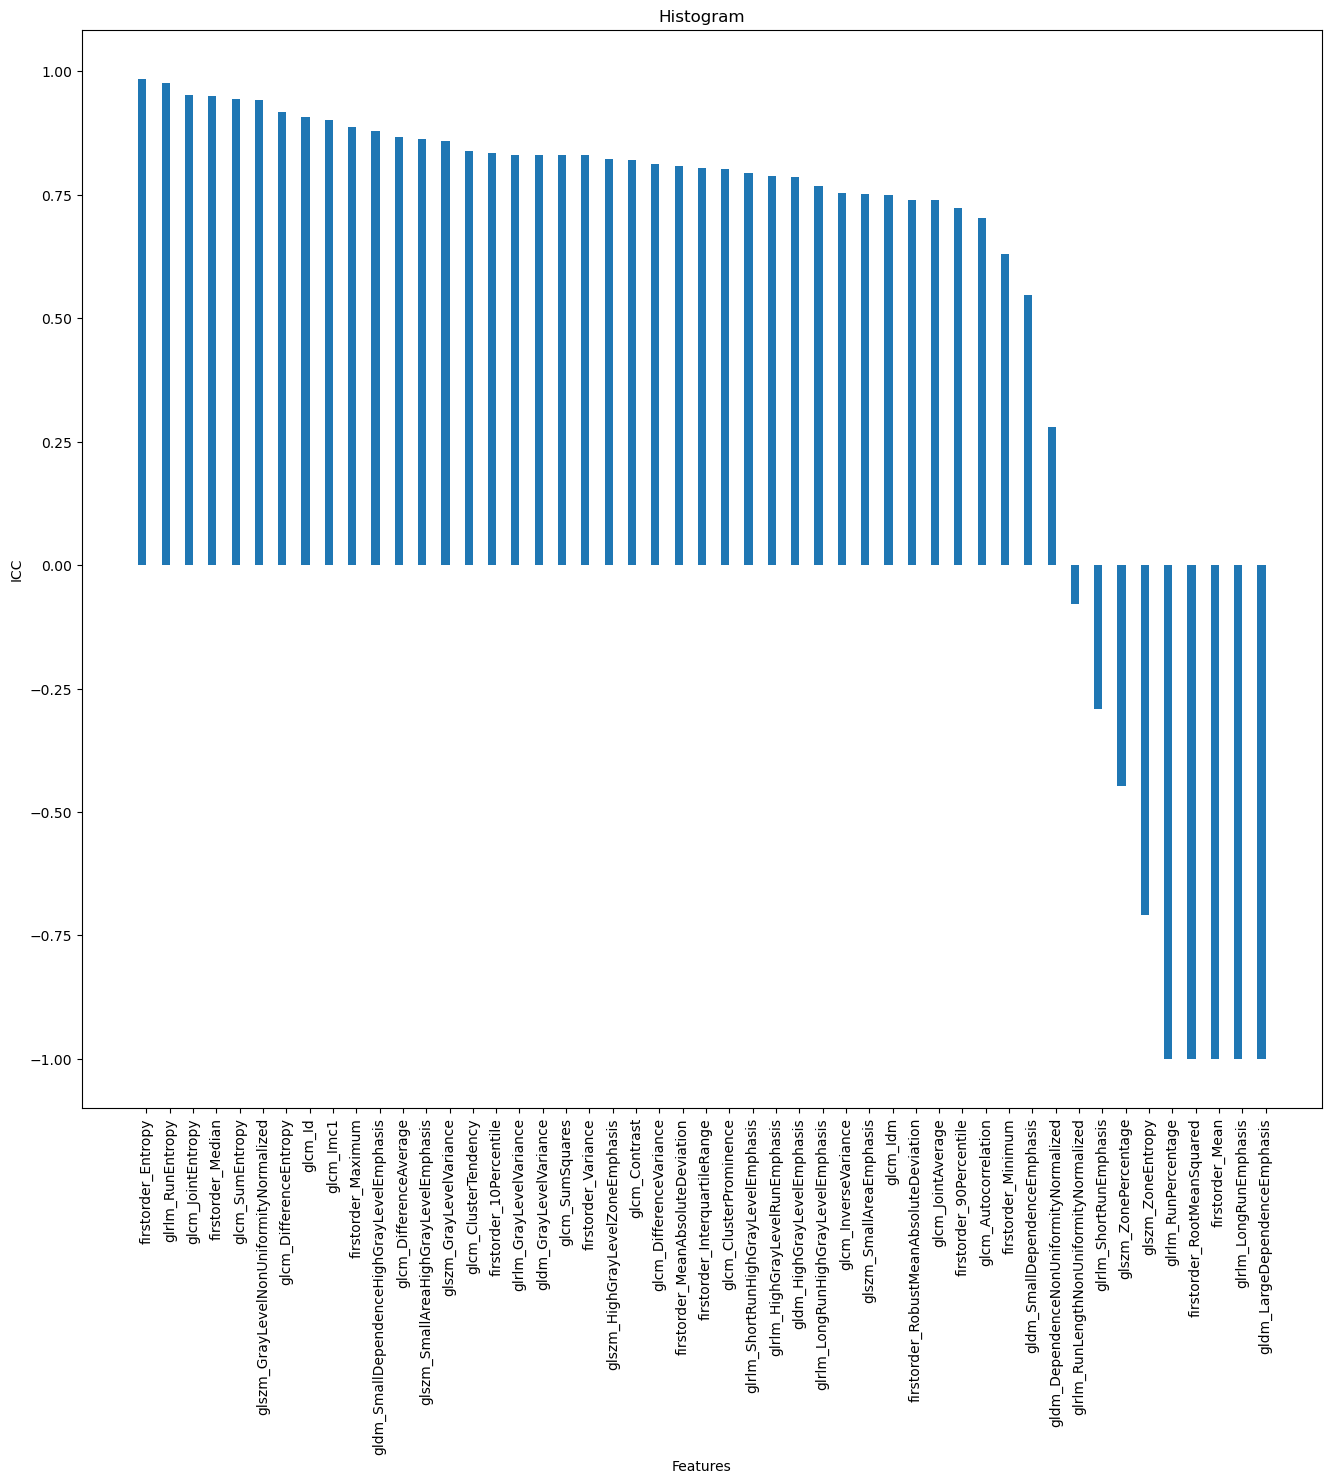

In [19]:
substring = 'original_'
new_column_names = []
for i in range(len(result_ALL['name'])):
    new_string = result_ALL['name'][i].replace(substring, "")
    new_column_names.append(new_string)

#Plot the histogram
plt.figure(figsize=(16,14))

transformed_numbers_all = [-1 if num < -1 else num for num in result_ALL['ICC']]
#transformed_numbers_dprime = [-1 if num < -1 else num for num in result_ALL['ICC_y']]

bar_width = 0.35

# Set the positions of the bars on the x-axis
bar_positions1 = np.arange(len(transformed_numbers_all))
bar_positions2 = bar_positions1 + bar_width

plt.bar(bar_positions1, transformed_numbers_all, bar_width, align='center', label='all')
#plt.bar(bar_positions2, transformed_numbers_dprime, bar_width, align='center', label = 'similar dprime')

# Set custom labels for the x-axis ticks
plt.xticks(bar_positions1 + bar_width/2, new_column_names, rotation=90)
#plt.xticks(rotation=90)

# Add labels and title

plt.xlabel('Features')
plt.ylabel('ICC')
plt.title('Histogram')

# Show the plot
plt.show()

In [20]:
Excellent_value_count = len(result_ALL[result_ALL['R'] == 'Excellent'])
print(f'Excellent:', Excellent_value_count)
Good_value_count = len(result_ALL[result_ALL['R'] == 'Good'])
print(f'Good:', Good_value_count)
Moderate_value_count = len(result_ALL[result_ALL['R'] == 'Moderate'])
print(f'Moderate:', Moderate_value_count)
Poor_value_count = len(result_ALL[result_ALL['R'] == 'Poor'])
print(f'Poor:', Poor_value_count)
Inconsistent_value_count = len(result_ALL[result_ALL['R'] == 'Inconsistent'])
print(f'Inconsistent:', Inconsistent_value_count)

Excellent: 9
Good: 23
Moderate: 7
Poor: 5
Inconsistent: 5


<Figure size 640x480 with 0 Axes>

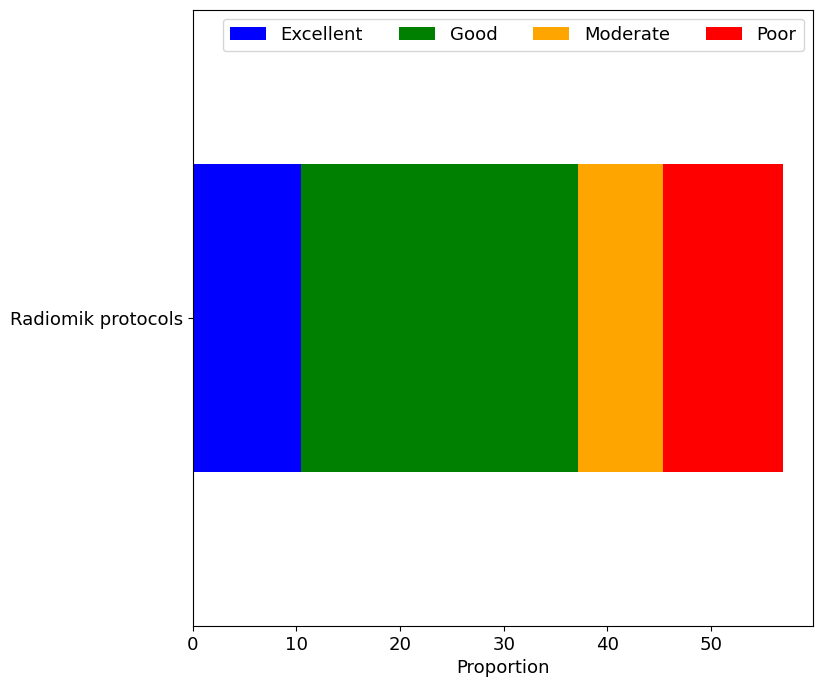

In [21]:
array = np.array([[Excellent_value_count*100/86, Good_value_count*100/86, Moderate_value_count*100/86, (Poor_value_count+Inconsistent_value_count)*100/86],  #[0*100/86, 34*100/86, 17*100/86, (11+24)*100/86]
                  ])


index_values = ['Radiomik protocols']
column_values = ['Excellent', 'Good', 'Moderate', 'Poor']
df_fig = pd.DataFrame(data = array,
                  index = index_values,
                  columns = column_values)

plt.figure()
df_fig.plot(kind="barh", figsize =(8, 8), fontsize=13, rot=0, stacked=True, color=['blue', 'green', 'orange', 'red'])
#plt.ylabel('Reconstruction Algorithm',fontsize=13)
plt.xlabel('Proportion',fontsize=13)
plt.legend(bbox_to_anchor =(1, 1),fontsize=13, ncol=4)
plt.savefig('Boxplot.png')